# 02 · Análisis Exploratorio de Datos (EDA)
### TP Analítica Descriptiva — PreEntrega 2 · Grupo 6 (PropTech)

Este notebook explora el dataset **procesado** generado en `01_calidad_y_limpieza`.
Cada bloque responde una pregunta o explora una hipótesis del proyecto; las técnicas
(análisis univariado, bivariado, correlaciones) se usan como herramientas al servicio
de esas preguntas, no como fin en sí mismas.

**Hipótesis que se exploran:**
- **H1** — Existe dispersión de precio/m² suficiente (dentro de barrio+tipología) para que puedan existir oportunidades.
- **H2** — La rentabilidad por alquiler difiere entre barrios premium y medios.
- **H3** — El precio/m² se relaciona con variables de contexto *(requiere fuentes externas; no evaluable aún)*.

**Foco:** operación de **venta** (dato principal); el alquiler se usa solo para el cálculo de rentabilidad (H2).



##Setup y definición del universo de análisis

In [1]:
import subprocess, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# --- Rutas relativas (mismo patrón que la notebook de limpieza) ---
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if not (RAIZ / "data" / "processed").exists():   # en Colab: clona el repo
    subprocess.run(["git", "clone", "-q",
                    "https://github.com/fedelachter/AD_Trabajo_Practico_G6"], check=True)
    RAIZ = Path.cwd() / "AD_Trabajo_Practico_G6"

PROCESSED = RAIZ / "data" / "processed"

# --- Importar funciones reutilizables de src/ ---          # ← NUEVO
sys.path.append(str(RAIZ))                                   # ← NUEVO: para que encuentre src
from src import eda                                          # ← NUEVO: las funciones del EDA

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# --- Carga del dataset procesado ---
df = pd.read_csv(PROCESSED / "propiedades_ml_limpio.csv")
print("Dataset procesado:", df.shape)

# --- Definición del universo de análisis ---
# Foco: venta, residencial, precio válido. Los emprendimientos se analizan aparte (bloque comparativo).
base = df[df["precio_valido"]].copy()                       # precio confiable
venta = base[(base["operacion"] == "venta") &
             (~base["posible_no_residencial"])].copy()       # venta, residencial

# Universo principal de oportunidades (H1): usados
venta_usados = venta[venta["es_emprendimiento"] == 0].copy()

print(f"\nVenta residencial (precio válido): {len(venta):,}")
print(f"  - usados:          {len(venta_usados):,}")
print(f"  - emprendimientos: {len(venta) - len(venta_usados):,}")
print(f"No-residenciales excluidos: {(base['operacion']=='venta').sum() - len(venta):,}")

Dataset procesado: (54789, 29)

Venta residencial (precio válido): 44,404
  - usados:          23,952
  - emprendimientos: 20,452
No-residenciales excluidos: 278


##Análisis univariado y asimetrías

Antes de relacionar variables, estudiamos cómo se distribuye cada una por separado.
El foco está en el **precio por m² (USD)** de las propiedades en **venta de usados**,
que es la variable central del análisis de oportunidades. Interesa especialmente la
**asimetría**: si la distribución tiene cola a la derecha, la media se distorsiona y
conviene trabajar con la **mediana** y estadísticos robustos.

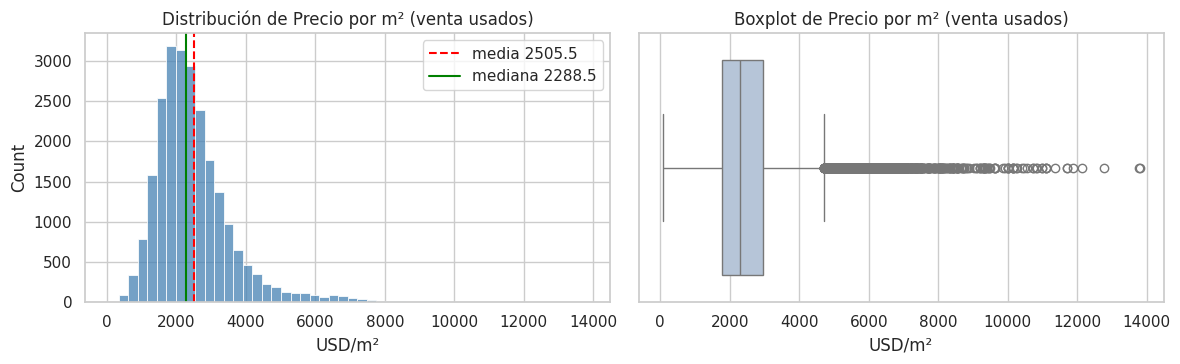

Precio por m² (venta usados)  |  n=23,902  nulos=50  media=2505.5  mediana=2288.5  skew=2.10


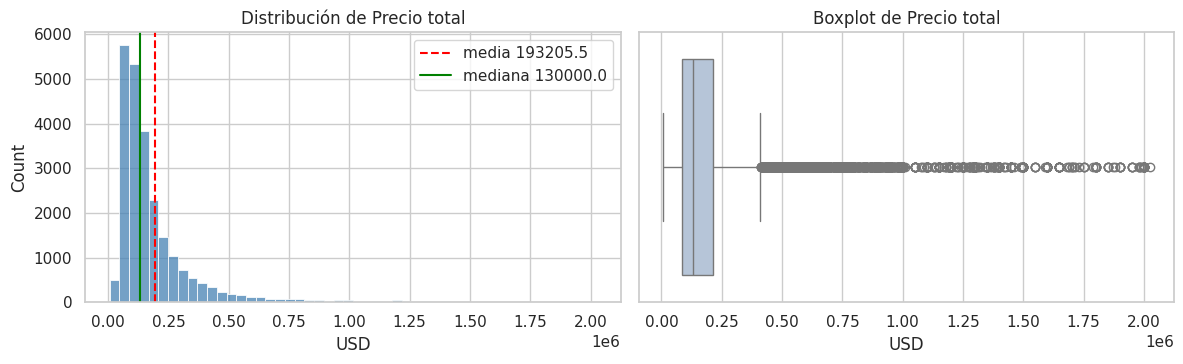

Precio total  |  n=23,952  nulos=0  media=193205.5  mediana=130000.0  skew=3.89


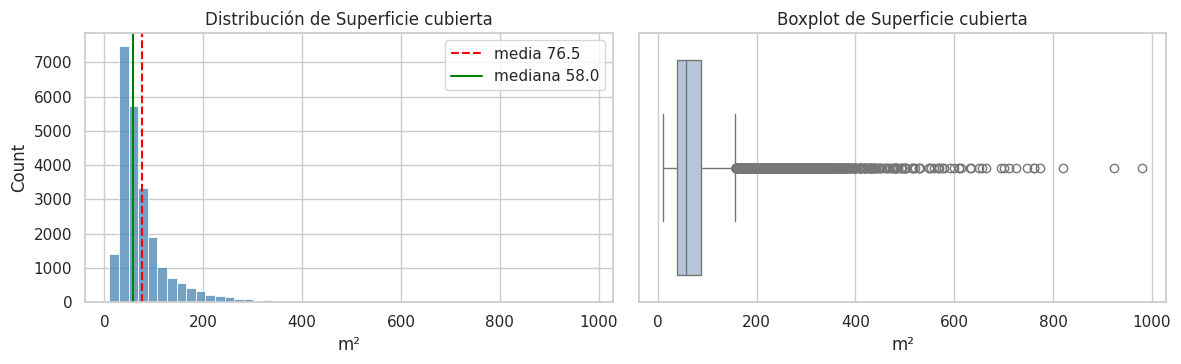

Superficie cubierta  |  n=23,902  nulos=50  media=76.5  mediana=58.0  skew=3.48


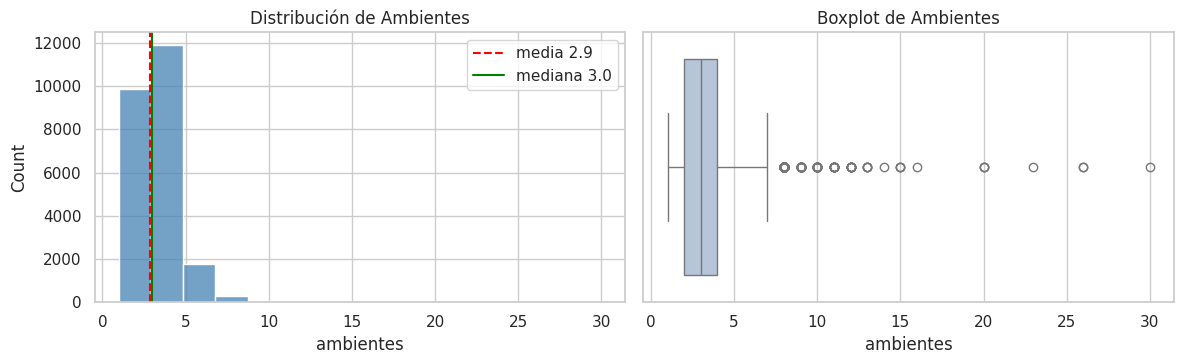

Ambientes  |  n=23,952  nulos=0  media=2.9  mediana=3.0  skew=2.12


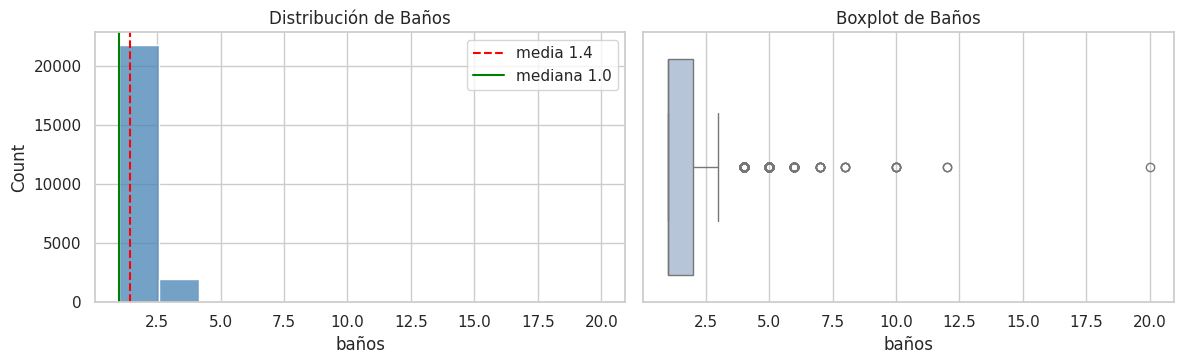

Baños  |  n=23,952  nulos=0  media=1.4  mediana=1.0  skew=2.99


In [2]:
eda_precio_m2 = eda.analisis_univariado(venta_usados["precio_m2"], "Precio por m² (venta usados)", "USD/m²")
eda_precio    = eda.analisis_univariado(venta_usados["precio_usd"], "Precio total", "USD")
eda_m2        = eda.analisis_univariado(venta_usados["m2_cubiertos"], "Superficie cubierta", "m²")
eda_amb       = eda.analisis_univariado(venta_usados["ambientes"], "Ambientes", "ambientes", bins=15)
eda_banos     = eda.analisis_univariado(venta_usados["banos"], "Baños", "baños", bins=12)

`precio_m2`: El precio por m² presenta asimetría positiva marcada (skew = 2,10): la mayoría de las propiedades se concentra entre USD 1.500 y 3.000/m², con una cola derecha de inmuebles premium que estira la distribución. La media (USD 2.505) queda por encima de la mediana (USD 2.288) por efecto de esos valores altos. Conclusión: se adopta la mediana como medida de referencia para el resto del análisis, por ser robusta ante estos extremos. La mediana de ~USD 2.288/m² es consistente con los valores de mercado de CABA.

`precio_usd`: El precio absoluto es la variable más asimétrica (skew = 3,89): la mediana es de USD 130.000, pero la media trepa a USD 193.000 por un grupo reducido de propiedades de muy alto valor. Esta fuerte asimetría refuerza la decisión de trabajar con medianas y de analizar el precio normalizado por m² en lugar del precio absoluto, para que propiedades de distinto tamaño sean comparables.

`m2_cubiertos`: La superficie también es asimétrica a la derecha (skew = 3,48): la vivienda típica ronda los 58 m² (mediana), con predominio de unidades chicas y medianas, y una cola de propiedades grandes. Hay 50 valores nulos (0,2%), que no se imputan por ser el denominador del precio/m². Los extremos del boxplot (hasta ~1.000 m²) se conservan por ser coherentes con casas/PH grandes.

`ambientes`: La oferta se concentra en unidades de 2 y 3 ambientes (mediana = 3). Los valores extremos (hasta ~30) que aparecen en el boxplot se conservaron en la limpieza por ser coherentes con su superficie (grandes propiedades o conjuntos). Recordar que una porción de esta variable fue imputada, por lo que conviene cautela al analizarla en detalle.

`banos`: La amplia mayoría de las propiedades tiene 1 baño (mediana = 1), con pocos casos de 2 o más. La fuerte asimetría (skew = 2,99) es esperable en una variable de conteo tan concentrada. Los extremos (hasta ~20) son escasos y corresponden a propiedades grandes.

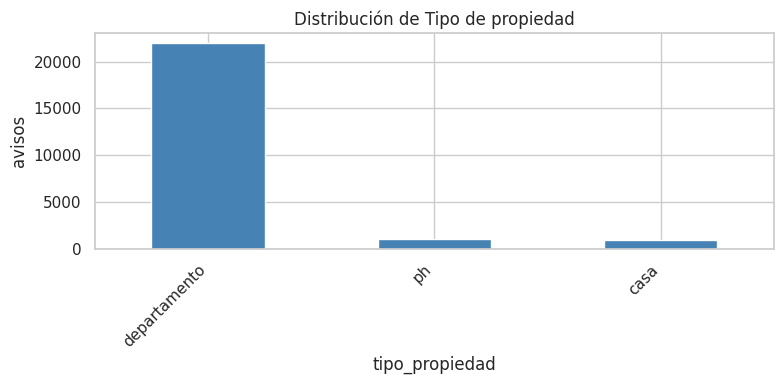

Tipo de propiedad  |  categorías: 3  |  n=23,952  nulos=0


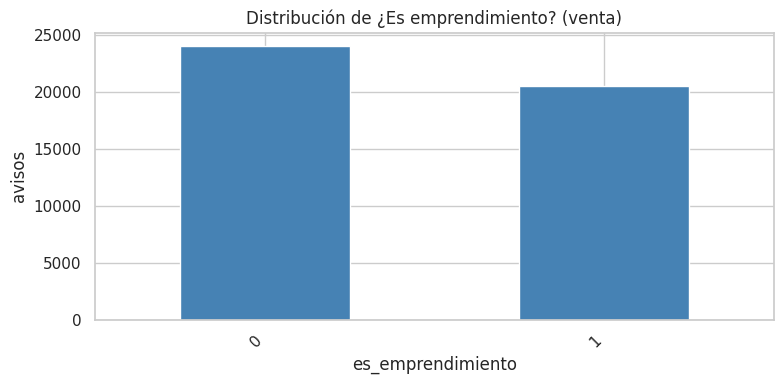

¿Es emprendimiento? (venta)  |  categorías: 2  |  n=44,404  nulos=0


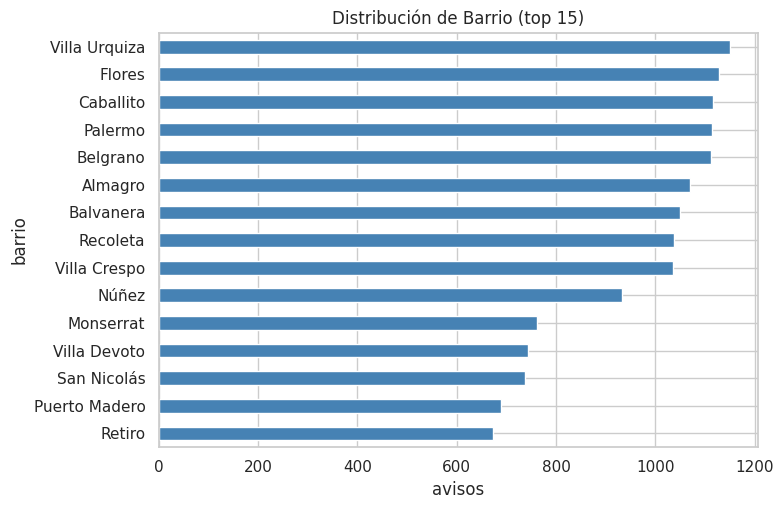

Barrio  |  categorías: 48  |  n=23,882  nulos=70


In [3]:
cat_tipo   = eda.analisis_categorico(venta_usados["tipo_propiedad"], "Tipo de propiedad")
cat_emp    = eda.analisis_categorico(venta["es_emprendimiento"], "¿Es emprendimiento? (venta)")  # sobre venta completa
cat_barrio = eda.analisis_categorico(venta_usados["barrio"], "Barrio", top=15, horizontal=True)  # top 15, horizontal

`tipo_propiedad`: El mercado de venta de usados está dominado por departamentos (la gran mayoría de los ~24.000 avisos), con participaciones marginales de PH y casas. Esto confirma el foco del análisis en el segmento de departamentos y advierte que las conclusiones sobre PH y casas tendrán menor respaldo muestral.

`es_emprendimiento`: La oferta de venta se reparte de forma relativamente pareja entre usados (24.000 aproximadamente) y emprendimientos (20.500 aproximadamente). Esta magnitud justifica haberlos separado: el análisis de oportunidades se concentra en usados (obra existente), mientras que los emprendimientos quedan disponibles para una comparación específica.

`barrio`: Los barrios con más avisos son Villa Urquiza, Flores, Caballito, Palermo y Belgrano. Sin embargo, este conteo NO debe interpretarse como el tamaño real del mercado de cada barrio: como se documentó en la limpieza, MercadoLibre impone un tope de resultados por búsqueda (~1.000-1.200), visible en que varios barrios grandes quedan "pegados" cerca de ese techo. Por lo tanto, la cantidad de avisos refleja la cobertura del scraping, no la oferta real. Para comparar barrios se usará el precio/m² (una medida de valor), no el volumen de avisos.

##Análisis bivariado y correlaciones

Exploramos cómo se relacionan las variables entre sí. Dos preguntas guían el bloque:
¿qué variables se asocian con el precio? y ¿el precio por m² cambia según el tamaño y
la tipología de la propiedad? Se mantiene el foco en **venta de usados** y se usan
estadísticos robustos, dada la asimetría detectada en el univariado.

###Analisis entre variables numéricas

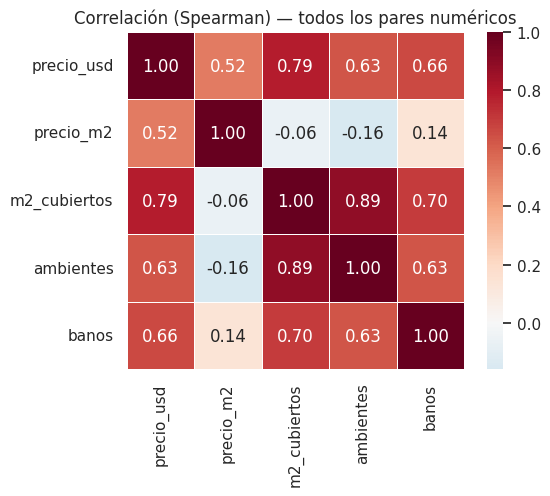

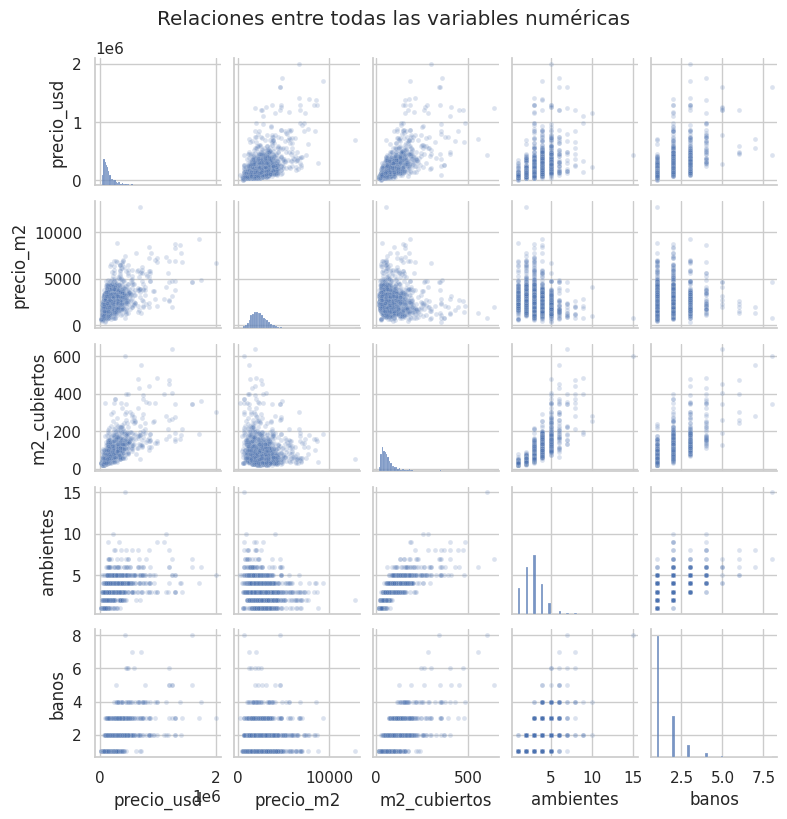

Par  |  rho (Spearman)  |  p-valor
precio_usd ~ precio_m2: rho=+0.52  p=0.0e+00
precio_usd ~ m2_cubiertos: rho=+0.79  p=0.0e+00
precio_usd ~ ambientes: rho=+0.63  p=0.0e+00
precio_usd ~ banos: rho=+0.66  p=0.0e+00
precio_m2 ~ m2_cubiertos: rho=-0.06  p=2.4e-22
precio_m2 ~ ambientes: rho=-0.16  p=2.2e-137
precio_m2 ~ banos: rho=+0.14  p=2.2e-100
m2_cubiertos ~ ambientes: rho=+0.89  p=0.0e+00
m2_cubiertos ~ banos: rho=+0.70  p=0.0e+00
ambientes ~ banos: rho=+0.63  p=0.0e+00


In [4]:
from scipy.stats import spearmanr

num_cols = ["precio_usd", "precio_m2", "m2_cubiertos", "ambientes", "banos"]

# Matriz de correlación (resume TODOS los pares num-num)
corr = venta_usados[num_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=.5, ax=ax)
ax.set_title("Correlación (Spearman) — todos los pares numéricos"); plt.tight_layout(); plt.show()

# Pairplot: scatter de TODOS los pares + distribución en la diagonal (sobre una muestra)
m = venta_usados[num_cols].dropna().sample(min(2000, len(venta_usados)), random_state=42)
g = sns.pairplot(m, plot_kws={"alpha": .2, "s": 12}, diag_kind="hist", height=1.6)
g.fig.suptitle("Relaciones entre todas las variables numéricas", y=1.02)
plt.show()

# Tabla de correlaciones con su p-valor (todos los pares)
import itertools
print("Par  |  rho (Spearman)  |  p-valor")
for a, b in itertools.combinations(num_cols, 2):
    d = venta_usados[[a, b]].dropna()
    rho, p = spearmanr(d[a], d[b])
    print(f"{a} ~ {b}: rho={rho:+.2f}  p={p:.1e}")

Las variables de tamaño están fuertemente correlacionadas entre sí, como era esperable: `m2_cubiertos` ~ `ambientes` (rho = 0,89), `m2_cubiertos` ~ `precio_usd` (0,79) y `ambientes` ~ `banos` (0,63). Son todas proxies del tamaño/valor de la propiedad, por lo que esta correlación es trivial y no aporta información nueva.

El hallazgo relevante aparece en el precio por m²: su correlación con el tamaño es negativa pero débil — `precio_m2` ~ `ambientes` (rho = −0,16) y `precio_m2` ~ `m2_cubiertos` (rho = −0,06). Es decir, a mayor cantidad de ambientes, el precio por m² tiende a bajar levemente: las unidades más grandes valen algo menos por metro. Esto es consistente con el "premium de las unidades chicas". La asociación es estadísticamente significativa (p muy bajo por el gran tamaño muestral) pero de magnitud pequeña, por lo que el tamaño explica solo una parte menor de la variación del precio/m².

###Analisis entre variables categóricas

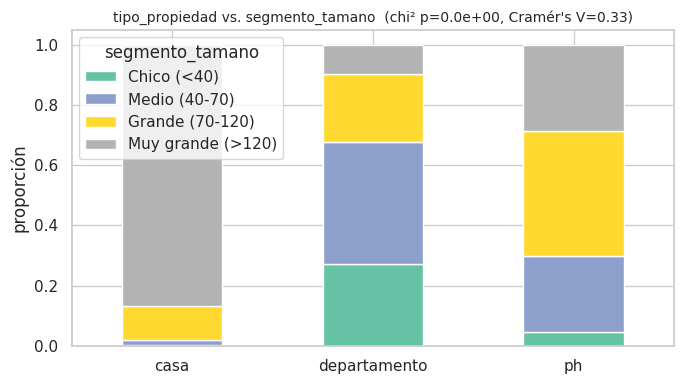

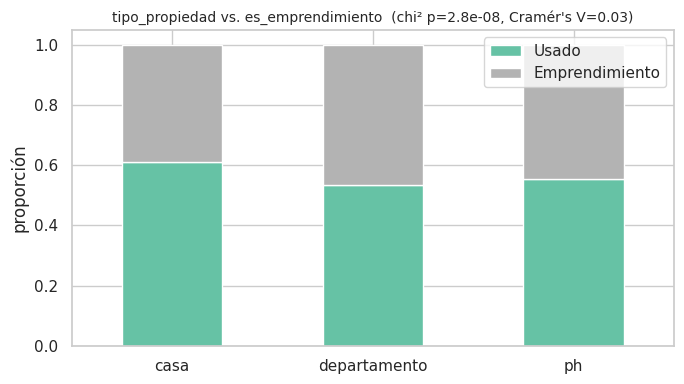

In [5]:
venta_usados["segmento_tamano"] = pd.cut(
    venta_usados["m2_cubiertos"], bins=[0, 40, 70, 120, np.inf],
    labels=["Chico (<40)", "Medio (40-70)", "Grande (70-120)", "Muy grande (>120)"])
venta_usados["es_monoambiente"] = (venta_usados["ambientes"] == 1).astype(int)



# --- Cruces cat-cat con sentido (ninguno cruza una variable con su "madre") ---
eda.barras_apiladas_cat_cat(venta_usados, "tipo_propiedad", "segmento_tamano")        # ¿casas/PH son más grandes?
eda.barras_apiladas_cat_cat(venta, "tipo_propiedad", "es_emprendimiento", ["Usado", "Emprendimiento"])  # los originales

Tipo de propiedad vs. segmento de tamaño (Cramér's V = 0,33, asociación moderada): existe una relación clara entre tipología y tamaño. Las casas se concentran en "Muy grande" (>120 m²), los PH en tamaños medios-grandes, y los departamentos en chico/medio (<70 m²). Es el cruce más informativo del bloque cat-cat y confirma que cada tipología ocupa un segmento de tamaño distinto.

Tipo de propiedad vs. emprendimiento (Cramér's V = 0,03, asociación prácticamente nula): la proporción usado/emprendimiento es similar en las tres tipologías (~55-60% usados en todas). Aunque el chi² da significativo (p ≈ 3e-8 por el gran N), el Cramér's V cercano a 0 indica que la relación es irrelevante en la práctica — la tipología no determina si algo es emprendimiento o no.

###Analisis entre variables categóricas y numéricas

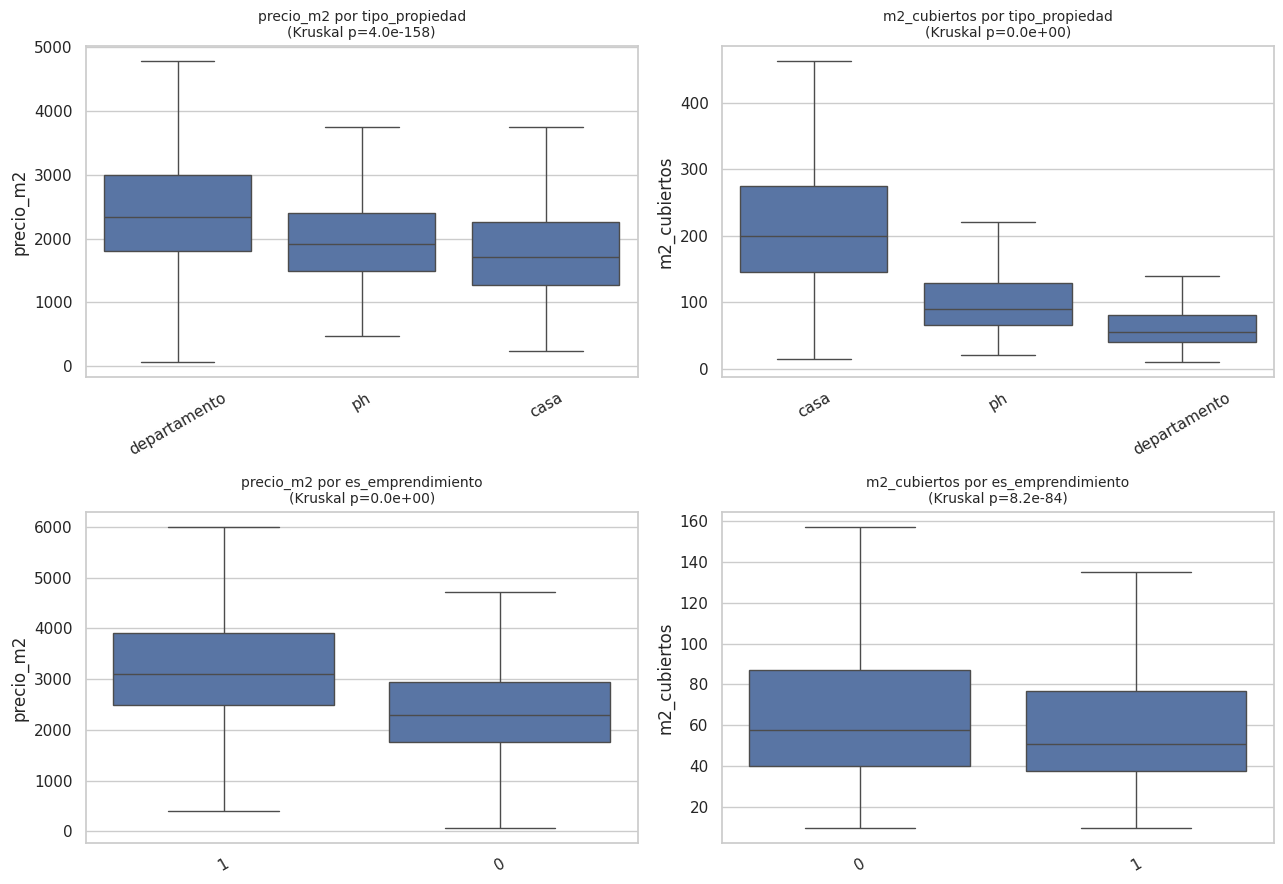

In [6]:


# Pares cat-num que aportan: {tipo, emprendimiento} × {precio_m2, m2}
pares_cn = [("tipo_propiedad", "precio_m2"), ("tipo_propiedad", "m2_cubiertos"),
            ("es_emprendimiento", "precio_m2"), ("es_emprendimiento", "m2_cubiertos")]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for (cat, num), ax in zip(pares_cn, axes.flat):
    datos = venta if cat == "es_emprendimiento" else venta_usados   # emprendimiento necesita venta completa
    eda.boxplot_cat_num(datos, cat, num, ax)
plt.tight_layout(); plt.show()

Precio/m² por tipología: el departamento es la tipología más cara por m² (mediana ~USD 2.300), por encima de PH y casa ( ~1.700-1.900). El test de Kruskal-Wallis confirma que la diferencia es significativa (p ≈ 4e-158). Tiene lógica: el depto maximiza valor por metro en zonas densas, mientras que casas y PH incluyen superficies (patios, terrazas) que diluyen el precio/m².

Tamaño por tipología: confirma lo esperado — las casas son mucho más grandes (mediana 200 m²) que los PH (95) y los departamentos (55). Coherente con la naturaleza de cada tipología.

Precio/m² por emprendimiento: los emprendimientos tienen un precio/m² marcadamente mayor que los usados (mediana ~3.100 vs. ~2.300), diferencia significativa (Kruskal p ≈ 0). Esto valida la decisión de separarlos: mezclarlos inflaría artificialmente el precio/m² del mercado. La obra nueva se paga más por metro.

Tamaño por emprendimiento: los emprendimientos son levemente más chicos (mediana ~50 vs. ~60 m²), consistente con que la obra nueva tiende a unidades compactas.

#Análisis orientado a las hipótesis

Hasta aquí exploramos los datos con técnicas generales. Ahora los ponemos a trabajar
sobre las hipótesis del proyecto.

##Dispersión de precio por m² dentro de grupos comparables (Hipótesis 1)

**H1** sostiene que existe una proporción relevante de propiedades cuyo precio se aparta
de su valor esperado, generando candidatas a subvaluación. Como paso previo —y sin un
modelo de valor de referencia todavía—, verificamos una condición necesaria: **que exista
dispersión de precio/m² dentro de grupos de propiedades comparables** (mismo barrio y
tipología). Si dentro de un grupo homogéneo todos los precios fueran casi iguales, no
habría margen para oportunidades.

> **Importante:** este análisis mide *dispersión*, no *subvaluación*. Una dispersión alta
> es condición necesaria pero no suficiente: puede deberse a diferencias de estado, calidad
> o microzona no observadas. La identificación de oportunidades reales requerirá el modelo
> de valor de referencia (Fase posterior).

Grupos analizados (n>=30): 68
CV mediano entre grupos: 0.30

--- Distribución del CV ---
count    68.00
mean      0.32
std       0.08
min       0.19
25%       0.27
50%       0.30
75%       0.35
max       0.64
Name: cv, dtype: float64


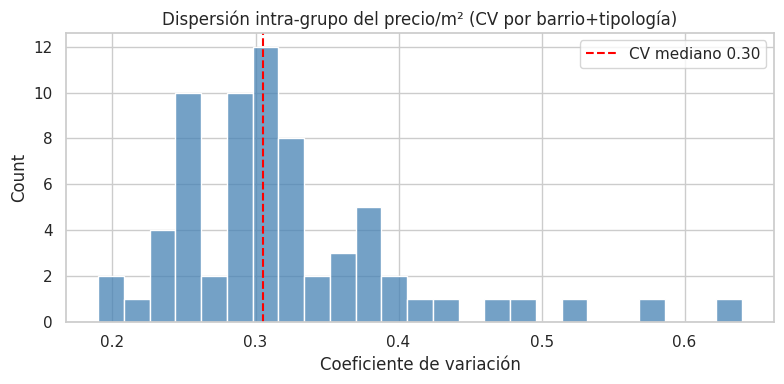

In [7]:
# Dispersión del precio/m² dentro de cada grupo (barrio + tipología)
# Medimos el coeficiente de variación (CV = desvío/media): dispersión relativa, comparable entre grupos.
g = (venta_usados
     .dropna(subset=["precio_m2"])
     .groupby(["barrio", "tipo_propiedad"])["precio_m2"]
     .agg(n="count", mediana="median", desvio="std"))
g = g[g["n"] >= 30].copy()                      # solo grupos con muestra suficiente
g["cv"] = (g["desvio"] / g["mediana"]).round(2)  # coeficiente de variación

print(f"Grupos analizados (n>=30): {len(g)}")
print(f"CV mediano entre grupos: {g['cv'].median():.2f}")
print("\n--- Distribución del CV ---")
print(g["cv"].describe().round(2))

# Visualización: cuán dispersos son los grupos
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(g["cv"], bins=25, ax=ax, color="steelblue")
ax.axvline(g["cv"].median(), color="red", ls="--", label=f"CV mediano {g['cv'].median():.2f}")
ax.set_title("Dispersión intra-grupo del precio/m² (CV por barrio+tipología)")
ax.set_xlabel("Coeficiente de variación"); ax.legend()
plt.tight_layout(); plt.show()

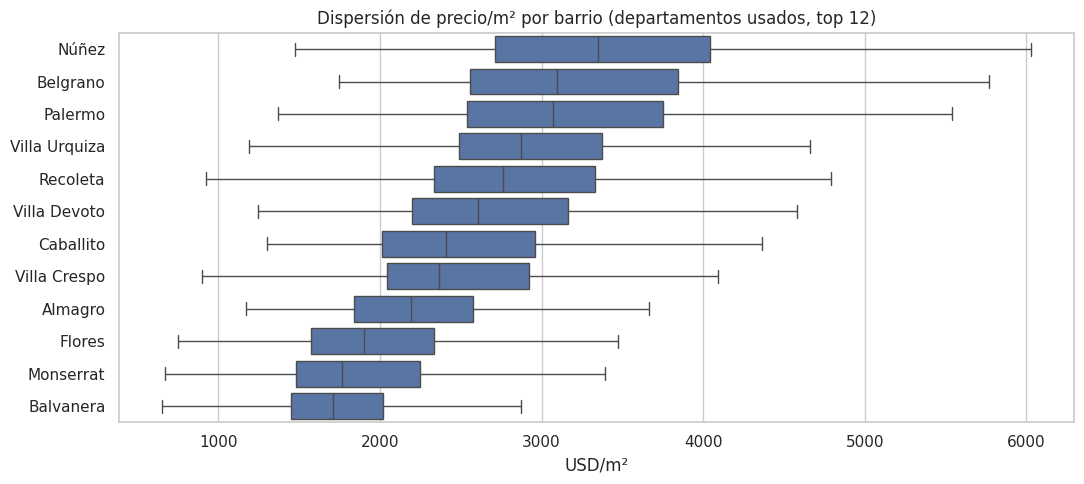

In [8]:
# Boxplot de precio/m² en los barrios con más avisos (deptos usados): ver la dispersión directamente
top_barrios = venta_usados["barrio"].value_counts().head(12).index
sub = venta_usados[(venta_usados["barrio"].isin(top_barrios)) &
                   (venta_usados["tipo_propiedad"] == "departamento") &
                   venta_usados["precio_m2"].notna()]
orden = sub.groupby("barrio")["precio_m2"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=sub, y="barrio", x="precio_m2", order=orden, showfliers=False, ax=ax)
ax.set_title("Dispersión de precio/m² por barrio (departamentos usados, top 12)")
ax.set_xlabel("USD/m²"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

Existe dispersión sustancial de precio por m² dentro de grupos comparables, lo que confirma la condición necesaria para la Hipótesis 1. Analizando los 68 grupos de barrio + tipología con muestra suficiente (n ≥ 30), el coeficiente de variación mediano es 0,30: es decir, aun entre propiedades del mismo barrio y la misma tipología, el precio por m² varía típicamente en torno a ±30% respecto de su media. La dispersión es consistente entre grupos (la mayoría se ubica entre un CV de 0,27 y 0,35), con casos que llegan hasta 0,64.

El boxplot por barrio lo muestra visualmente: en todos los barrios las cajas son anchas, no líneas finas. Por ejemplo, en Núñez los departamentos usados van desde ~USD 2.800 hasta ~USD 4.000/m² dentro del rango intercuartílico, y Belgrano o Palermo muestran amplitudes similares. Esta heterogeneidad interna es precisamente el margen donde pueden existir oportunidades de compra por debajo del valor esperado.

Interpretación y alcance: este resultado aporta evidencia preliminar a favor de H1 —hay suficiente variación de precios como para que existan candidatas a subvaluación—, pero no la valida. La dispersión observada puede deberse en parte a diferencias no observadas (estado de conservación, calidad constructiva, microzona dentro del barrio) y no solo a oportunidades reales. La separación entre "barato-oportunidad" y "barato-justificado" requiere estimar un precio de referencia por propiedad mediante un modelo de regresión y analizar los residuos, tarea que corresponde a la fase de modelado posterior.

##Precio por m² entre barrios (ubicación y antesala de H3)

El análisis anterior mostró la dispersión *dentro* de cada barrio. Ahora comparamos los
barrios *entre sí*: ¿cuánto pesa la ubicación en el precio por m²? Este análisis ordena
los barrios por valor y prepara el terreno para la Hipótesis 3 (relación del precio con
variables de contexto), que no podrá evaluarse plenamente hasta integrar las fuentes externas.

Barrios analizados: 46
Barrio más caro:  Puerto Madero (USD 5990/m²)
Barrio más barato: Villa Soldati (USD 1000/m²)
Ratio caro/barato: 6.0x


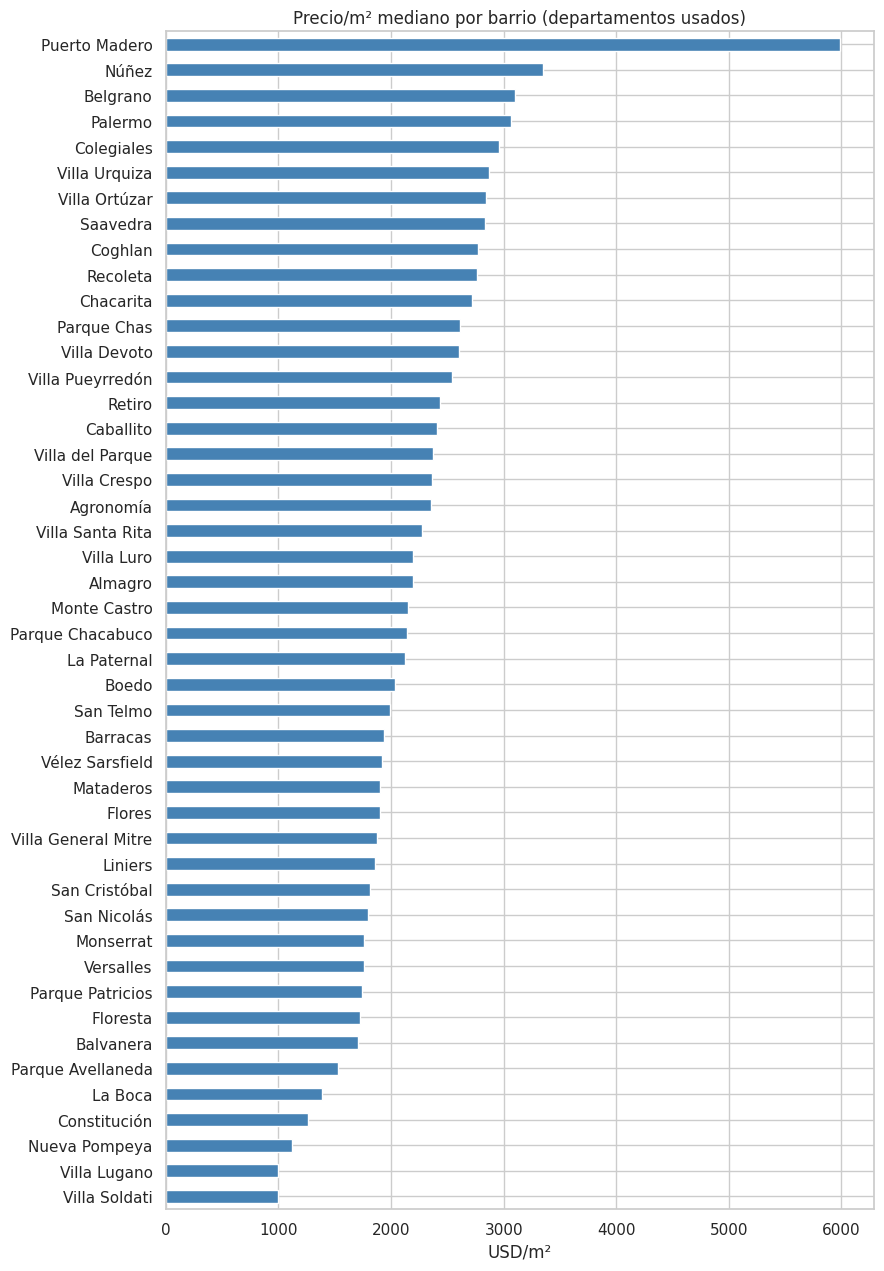

In [9]:
# Ranking de barrios por precio/m² mediano (departamentos usados, con muestra suficiente)
depto = venta_usados[(venta_usados["tipo_propiedad"] == "departamento") & venta_usados["precio_m2"].notna()]
rank = (depto.groupby("barrio")["precio_m2"]
        .agg(n="count", mediana="median")
        .query("n >= 30")
        .sort_values("mediana", ascending=False))

print(f"Barrios analizados: {len(rank)}")
print(f"Barrio más caro:  {rank.index[0]} (USD {rank['mediana'].iloc[0]:.0f}/m²)")
print(f"Barrio más barato: {rank.index[-1]} (USD {rank['mediana'].iloc[-1]:.0f}/m²)")
print(f"Ratio caro/barato: {rank['mediana'].iloc[0] / rank['mediana'].iloc[-1]:.1f}x")

# Gráfico: ranking completo
fig, ax = plt.subplots(figsize=(9, max(5, len(rank)*0.28)))
rank["mediana"].sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("Precio/m² mediano por barrio (departamentos usados)")
ax.set_xlabel("USD/m²"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

La ubicación es un determinante de primer orden del precio por m². Analizando los 46 barrios con muestra suficiente (departamentos usados, n ≥ 30), el precio por m² mediano va desde USD 5.990 en Puerto Madero (el más caro) hasta USD 1.000 en Villa Soldati (el más barato): una brecha de 6,0x entre extremos. Es decir, el mismo metro cuadrado de departamento vale seis veces más según el barrio.

El ranking reproduce con nitidez la geografía de valor de CABA: en la cima se ubican Puerto Madero y el corredor norte premium (Núñez, Belgrano, Palermo, Colegiales, Recoleta), seguidos por barrios del norte medio (Villa Urquiza, Saavedra); en la base, barrios del sur (Villa Soldati, Villa Lugano, Nueva Pompeya, La Boca). La transición es gradual y geográficamente coherente, lo que da confianza en la calidad del dato.

Interpretación y conexión con las hipótesis: esta brecha de 6x cuantifica cuánto pesa la ubicación en el precio, y justifica por qué el análisis de oportunidades debe hacerse dentro de cada barrio y no mezclando barrios (una propiedad "barata" en Puerto Madero puede ser más cara que una "cara" en Soldati). Refuerza la decisión metodológica de la H1 de comparar siempre dentro de grupos homogéneos. Además, es la antesala de la H3: el hecho de que el precio varíe tan fuerte por zona sugiere que variables de contexto asociadas a la ubicación (transporte, seguridad, nivel de la zona) se relacionan con el valor —relación que podrá cuantificarse recién al integrar las fuentes externas en la fase posterior—.

## Rentabilidad por alquiler por barrio (Hipótesis 2)

**H2** sostiene que los barrios premium tienen menor rentabilidad por alquiler que los
de valor medio/bajo. Para explorarlo cruzamos las dos operaciones a nivel de barrio:
la **rentabilidad bruta** se estima como el alquiler anual mediano de la zona dividido
por el precio de venta mediano de la misma zona y tipología.

> **Alcance:** esta es la rentabilidad **bruta** (no descuenta vacancia, expensas,
> impuestos ni costos de transacción). Es evidencia preliminar; la rentabilidad **neta**
> —necesaria para una conclusión de inversión— requiere esos costos y se calculará en la
> fase posterior. Además, se trabaja con medianas por barrio (no por propiedad individual),
> ya que una misma unidad no está simultáneamente en venta y alquiler.

In [10]:
# Preparar alquiler residencial (mismo criterio que venta: precio válido, no-residencial excluido)
alquiler = base[(base["operacion"] == "alquiler") & (~base["posible_no_residencial"])].copy()

# Trabajamos con departamentos (tipología dominante y comparable entre venta/alquiler)
TIPO = "departamento"
vd = venta_usados[(venta_usados["tipo_propiedad"] == TIPO) & venta_usados["precio_usd"].notna()]
ad = alquiler[(alquiler["tipo_propiedad"] == TIPO) & alquiler["precio_usd"].notna()]

# Medianas por barrio (en USD), con muestra mínima en AMBAS operaciones
venta_bar   = vd.groupby("barrio")["precio_usd"].agg(precio_venta="median", n_venta="count")
alquiler_bar = ad.groupby("barrio")["precio_usd"].agg(alquiler_mes="median", n_alq="count")

rent = venta_bar.join(alquiler_bar, how="inner")
rent = rent[(rent["n_venta"] >= 30) & (rent["n_alq"] >= 20)].copy()

# Rentabilidad bruta anual = (alquiler mensual * 12) / precio de venta
rent["rent_bruta_%"] = (rent["alquiler_mes"] * 12 / rent["precio_venta"] * 100).round(2)
rent = rent.sort_values("rent_bruta_%", ascending=False)

print(f"Barrios con datos de venta y alquiler: {len(rent)}")
print(f"Rentabilidad bruta mediana: {rent['rent_bruta_%'].median():.2f}% anual")
print(rent[["precio_venta", "alquiler_mes", "rent_bruta_%"]].round(0))

Barrios con datos de venta y alquiler: 40
Rentabilidad bruta mediana: 5.14% anual
                     precio_venta  alquiler_mes  rent_bruta_%
barrio                                                       
Villa Lugano              57000.0         437.0           9.0
La Boca                   69900.0         453.0           8.0
Parque Avellaneda         80000.0         518.0           8.0
Constitución              63000.0         388.0           7.0
Parque Patricios          82000.0         434.0           6.0
San Nicolás               85000.0         450.0           6.0
Mataderos                 98000.0         518.0           6.0
Monserrat                 90000.0         472.0           6.0
San Cristóbal             84800.0         440.0           6.0
Boedo                     89000.0         460.0           6.0
Villa General Mitre       92000.0         453.0           6.0
Liniers                   93000.0         453.0           6.0
San Telmo                 99900.0         485.0   

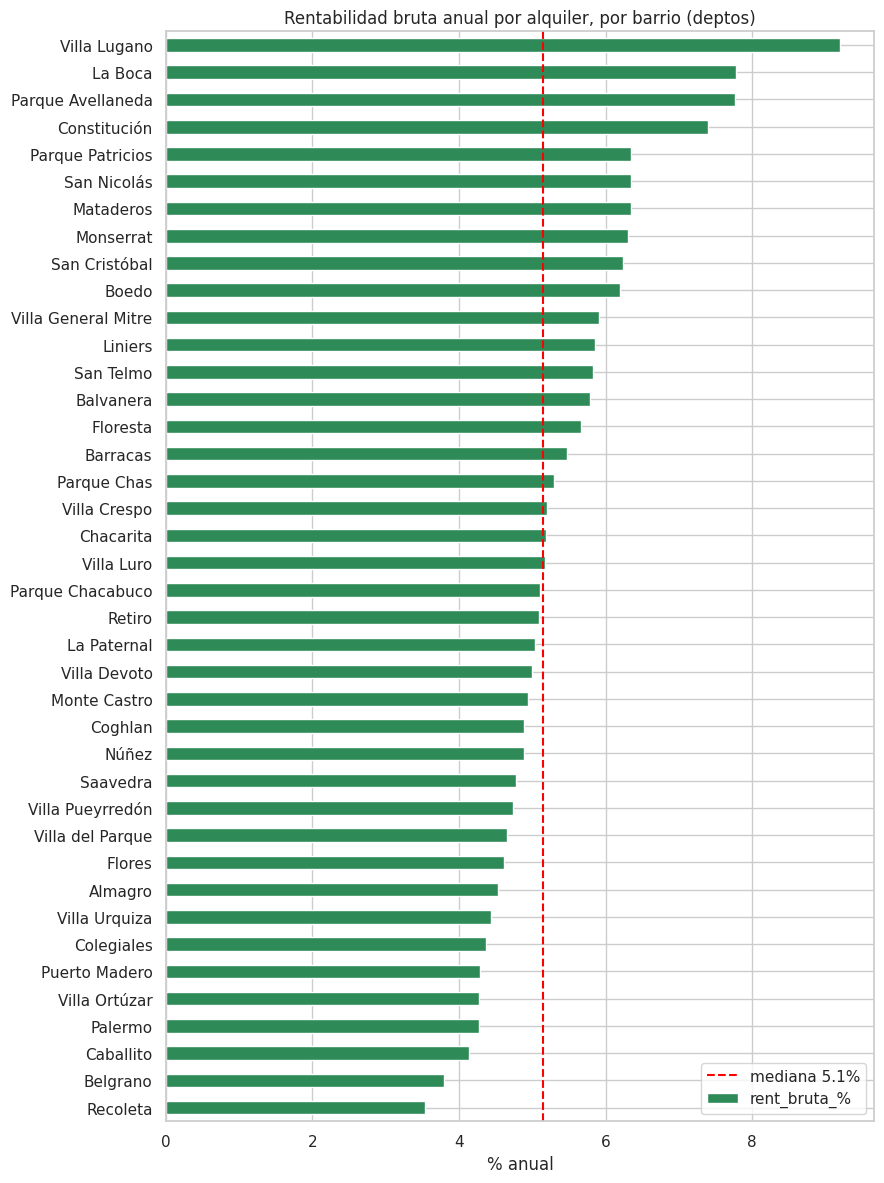

         count  median
grupo                 
Premium      4    4.04
Resto       36    5.19

Mann-Whitney (premium < resto): p=0.001


In [11]:
# Gráfico: rentabilidad por barrio
fig, ax = plt.subplots(figsize=(9, max(5, len(rent)*0.3)))
rent["rent_bruta_%"].sort_values().plot.barh(ax=ax, color="seagreen")
ax.axvline(rent["rent_bruta_%"].median(), color="red", ls="--", label=f"mediana {rent['rent_bruta_%'].median():.1f}%")
ax.set_title("Rentabilidad bruta anual por alquiler, por barrio (deptos)")
ax.set_xlabel("% anual"); ax.set_ylabel(""); ax.legend()
plt.tight_layout(); plt.show()

# Test de H2: ¿los premium rinden menos que el resto?
premium = ["Puerto Madero", "Palermo", "Recoleta", "Belgrano"]
rent["grupo"] = np.where(rent.index.isin(premium), "Premium", "Resto")
print(rent.groupby("grupo")["rent_bruta_%"].agg(["count", "median"]).round(2))

from scipy.stats import mannwhitneyu
g1 = rent[rent.grupo == "Premium"]["rent_bruta_%"]
g2 = rent[rent.grupo == "Resto"]["rent_bruta_%"]
stat, p = mannwhitneyu(g1, g2, alternative="less")   # H2: premium < resto
print(f"\nMann-Whitney (premium < resto): p={p:.3f}")

Los datos aportan evidencia clara a favor de la Hipótesis 2. Cruzando venta y alquiler a nivel de barrio (40 barrios con muestra suficiente en ambas operaciones), la rentabilidad bruta anual mediana del mercado es 5,1%, un valor coherente con el mercado inmobiliario de CABA.

La relación con el nivel del barrio es inversa y marcada: los barrios de mayor rentabilidad son los de valor medio/bajo —Villa Lugano (9%), La Boca (8%), Parque Avellaneda (8%), Constitución (7%)—, mientras que los barrios premium quedan en el fondo del ranking —Recoleta, Belgrano, Palermo y Puerto Madero, todos en torno al 4%—. Dicho de otro modo: comprar para alquilar rinde casi el doble en los barrios populares que en los premium.

El contraste estadístico lo confirma: la rentabilidad mediana del grupo premium es 4,04% frente a 5,19% del resto, y el test de Mann-Whitney (hipótesis direccional premium < resto) da p = 0,001, rechazando que los premium rindan igual o más. La diferencia es significativa y del signo esperado.

La explicación económica es la "paradoja" que anticipaba H2: en los barrios caros, el precio de venta se dispara (Puerto Madero: USD 560.000 de mediana) pero el alquiler no acompaña en la misma proporción (USD 2.000/mes), comprimiendo la rentabilidad. En los barrios populares, el precio de compra bajo (Villa Lugano: USD 57.000) hace que incluso un alquiler modesto represente un retorno proporcional mayor.

Alcance: esta es la rentabilidad bruta. La conclusión de inversión definitiva requiere la rentabilidad neta —descontando vacancia, expensas, impuestos y mantenimiento—, costos que impactan proporcionalmente más en los barrios populares (donde el alquiler absoluto es menor) y que podrían reducir parte de la brecha observada. Ese cálculo corresponde a la fase posterior. La evidencia preliminar, no obstante, es consistente y robusta.

 ## Fuentes externas y viabilidad para la Hipótesis 3

**H3** sostiene que el precio por m² se relaciona con variables de contexto del entorno
(transporte, seguridad, comercios). Estas variables **no están en el dataset actual** —
provienen de fuentes externas aún no integradas—, por lo que **H3 no puede evaluarse en
esta entrega**. El análisis por barrio (Bloque 4) mostró que la ubicación pesa fuertemente
en el precio (brecha de 6x entre barrios), lo cual es *consistente* con H3 pero no la prueba:
confirmarla requiere medir el contexto y relacionarlo con el precio dentro de grupos comparables.

A continuación se documenta la **viabilidad** de cada fuente externa priorizada, para demostrar
su compatibilidad con la unidad de análisis (el barrio) antes de integrarlas en la fase posterior.

| Fuente | Organismo | Granularidad | Mecanismo de unión | Variable derivada | Aporta a | Limitaciones |
|---|---|---|---|---|---|---|
| Subte, Metrobus, tren, premetro | BA Data (GCBA) | Georreferenciada | Conteo de estaciones por barrio (join espacial) | Densidad de transporte | H3 | No distingue frecuencia ni capacidad |
| Mapa del delito | BA Data (GCBA) | Barrio o comuna (a confirmar) | Delitos por barrio / 1.000 hab. | Índice de inseguridad | H3 | Subregistro; posible nivel comuna |
| Comercios / habilitaciones | BA Data (GCBA) | Georreferenciada | Conteo de comercios por barrio (join espacial) | Nivel de oferta comercial | H3 | Heterogeneidad de rubros |
| Polígonos de barrios/comunas | BA Data (GCBA) | Barrio (límites oficiales) | Base geográfica para los joins | Asignación de barrio | Soporte | Requiere geocodificar direcciones |
| Tipo de cambio histórico | bluelytics (API) | Diaria | Por fecha (ARS→USD) | Precio en USD | Soporte (aplicada) | Corte único en esta fase |

Todas las fuentes cubren CABA y corresponden al período vigente/actual.

**Compatibilidad con la unidad de análisis.** Las fuentes georreferenciadas (transporte,
comercios, polígonos) son plenamente compatibles con el análisis por barrio. El mapa del delito
es el único con riesgo de estar agregado a nivel comuna; de confirmarse, se documentará esa
limitación —una comuna agrupa varios barrios— y se evaluará su uso a nivel comuna como aproximación.

## Conclusiones del análisis exploratorio

### Principales hallazgos
- El mercado de venta de usados está **dominado por departamentos**, concentrados en unidades
  de 2-3 ambientes y ~58 m² (mediana). El precio por m² mediano es de **USD 2.288**, coherente
  con el mercado de CABA.
- **La ubicación es el principal determinante del precio**: el precio/m² mediano por barrio va
  de USD 5.990 (Puerto Madero) a USD 1.000 (Villa Soldati), una **brecha de 6x**. El ranking
  reproduce fielmente la geografía de valor de la ciudad.
- **El precio/m² es casi independiente del tamaño** (correlación de Spearman ≈ 0 con m² y
  ambientes), lo que lo vuelve una medida limpia para comparar propiedades heterogéneas.
- Los **emprendimientos tienen un precio/m² marcadamente mayor** que los usados (mediana ~3.100
  vs. ~2.300), lo que justificó analizarlos por separado.

### Problemas de calidad detectados
(Analizados y tratados en detalle en `01_calidad_y_limpieza`.)
- Mezcla de monedas (ARS/USD) en alquiler; nombres de barrio no normalizados (181 variantes);
  duplicados no detectables por ID; valores imposibles en ambientes/baños/m²; avisos de tipología
  no residencial; y un **tope de captura (~1.200 avisos) por barrio** en el scraping.

### Decisiones de limpieza adoptadas
(Detalladas en `01`.) Normalización de barrios a los 48 oficiales; homogeneización a USD con
dólar blue documentado; imputación de ambientes/baños tras split train/test (anti-leakage);
no imputación de m²; marcado (no eliminación) de atípicos y no residenciales. Este EDA parte del
dataset ya procesado y usa **estadísticos robustos** (mediana, cuantiles) coherentes con esas decisiones.

### Hipótesis con evidencia preliminar
- **H1 (oportunidades):** evidencia **a favor**. Existe dispersión sustancial de precio/m² dentro
  de grupos comparables (CV mediano = 0,30), condición necesaria para que existan candidatas a
  subvaluación.
- **H2 (rentabilidad premium vs. resto):** evidencia **a favor y significativa**. La rentabilidad
  bruta de los barrios premium (4,0%) es menor que la del resto (5,2%); Mann-Whitney p = 0,001.

### Hipótesis que aún no pueden evaluarse
- **H3 (contexto):** **no evaluable** en esta entrega. Requiere integrar las fuentes externas
  (transporte, seguridad, comercios), cuya viabilidad y compatibilidad con la unidad de análisis
  quedó documentada (Bloque 6). El fuerte efecto de la ubicación sobre el precio es *consistente*
  con H3, pero no la prueba.

### Limitaciones del dataset
- **Corte temporal único**: sin análisis de evolución ni valorización futura.
- **Sin fechas por aviso** y **tope de captura por barrio**: el volumen de avisos no mide la oferta real.
- La **rentabilidad es bruta** (sin costos); la neta puede reducir la brecha entre barrios.
- Parte de `ambientes` fue imputada; conviene cautela en análisis finos de esa variable.
- La conversión a USD usa una cotización de fecha fija (corte único).

### Próximos pasos (hacia el modelado)
1. **Modelo de valor de referencia** (regresión de precio/m² por atributos) para calcular residuos
   e identificar oportunidades reales → validación plena de H1.
2. **Integrar fuentes externas** y construir el índice de Contexto → evaluación de H3.
3. **Rentabilidad neta** (descontando vacancia, expensas, impuestos y costos de transacción) y
   retornos de reventa → comparación de estrategias y validación completa de H2.
4. Construir el **Score de atractivo de inversión** integrando los tres componentes.